In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# DIFMAP PYTHON WRAPPER - DÉMONSTRATION COMPLÈTE
# ═══════════════════════════════════════════════════════════════════════════════
# Ce notebook démontre les capacités du wrapper Python pour Difmap :
#   • Chargement et sélection des données UV
#   • Imagerie (Dirty Map, Clean Map, Residual Map)
#   • Contrôle complet des paramètres CLEAN (niter, gain, cutoff)
#   • Gestion des fenêtres CLEAN (addwin, peakwin, delwin)
#   • Auto-calibration (selfcal)
#   • Extraction des composantes du modèle
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
from difmap_wrapper import DifmapSession

# ── PARAMÈTRES DE LA DÉMO ──────────────────────────────────────────────────────
DATA_PATH      = "tests/test_data/0003-066_X.SPLIT.1"  # Fichier FITS-UV
REQUESTED_POL  = "RR"                                   # Polarisation
REQUESTED_IFS  = (1, 0)                                 # (premier, dernier) ; 0 = tous

# Imagerie
MAP_SIZE       = 512    # Grille en pixels (puissance de 2)
CELL_SIZE_MAS  = 0.1    # Taille pixel en milliarcsecondes

# CLEAN - Paramètres pour la démo
CLEAN_NITER    = 100   # Négatif = arrêt au 1er composant négatif
CLEAN_GAIN     = 0.05    # Gain de boucle (typique: 0.05-0.2)
CLEAN_CUTOFF   = 0.000 # Seuil de flux (Jy/beam) - arrêt automatique

# ── FONCTIONS UTILITAIRES ──────────────────────────────────────────────────────
def format_if_range(ifs):
    """Convertit (1, 2) → '1..2', (1, 0) → 'tous'."""
    a, b = ifs
    return "tous" if b == 0 else f"{a}..{b}"

def unique_ifs(data):
    """Retourne la liste triée des IFs présents."""
    return sorted(set(int(x) for x in np.unique(data["if_no"])))

def print_beam_info(session):
    """Affiche les paramètres du faisceau synthétique."""
    beam = session.imager._native.get_beam_info()
    print(f"Beam: BMAJ={beam['BMAJ']:.3f} mas, BMIN={beam['BMIN']:.3f} mas, BPA={beam['BPA']:.1f}°")
    print(f"RMS: {beam['RMS']*1000:.3f} mJy/beam")

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

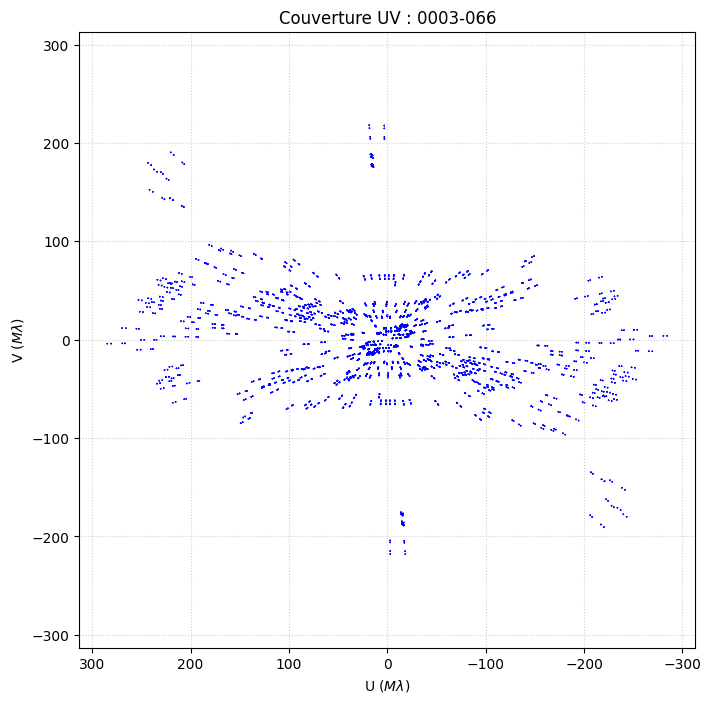

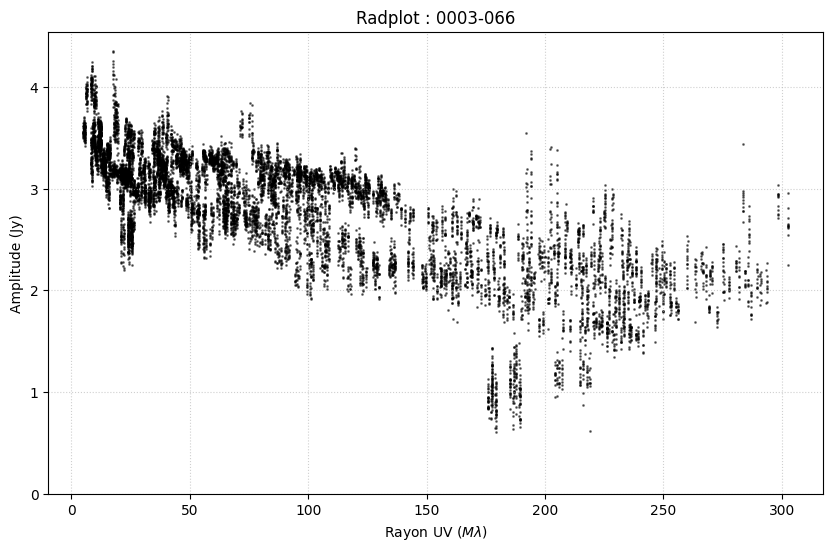

Polarisation I indisponible. Le moteur a basculé sur RR.
Polarization I is unavailable.


Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


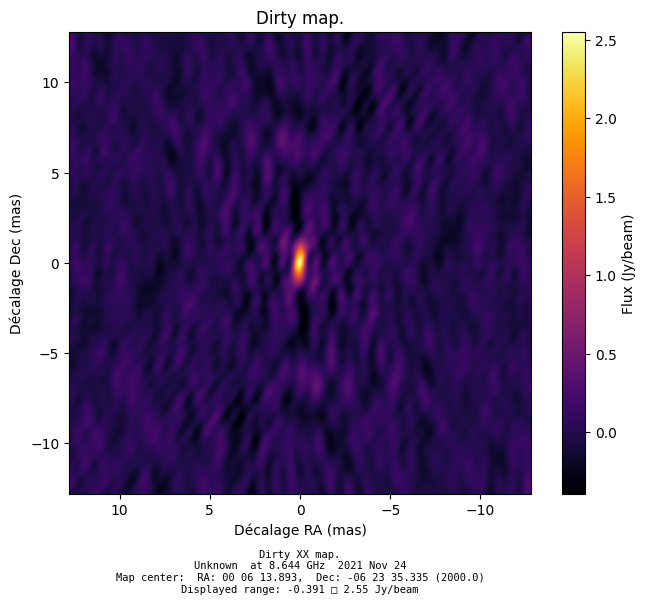

Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
Component: 050  -  total flux cleaned = 2.40333 Jy
Component: 100  -  total flux cleaned = 2.90978 Jy
Component: 150  -  total flux cleaned = 3.15006 Jy
Component: 200  -  total flux cleaned = 3.24741 Jy
Component: 250  -  total flux cleaned = 3.29978 Jy
Component: 300  -  total flux cleaned = 3.32393 Jy
Component: 350  -  total flux cleaned = 3.33454 Jy
Component: 400  -  total flux cleaned = 3.3503 Jy
Component: 450  -  total flux cleaned = 3.35308 Jy
Component: 500  -  total flux cleaned = 3.36135 Jy
Total flux subtracted in 500 components = 3.36135 Jy
Clean residual min=-0.026194 max=0.026124 Jy/beam
Clean residual mean=0.000292 rms=0.009684 Jy/beam
Clean map  min=-0.046328  max=2.5678 Jy/beam


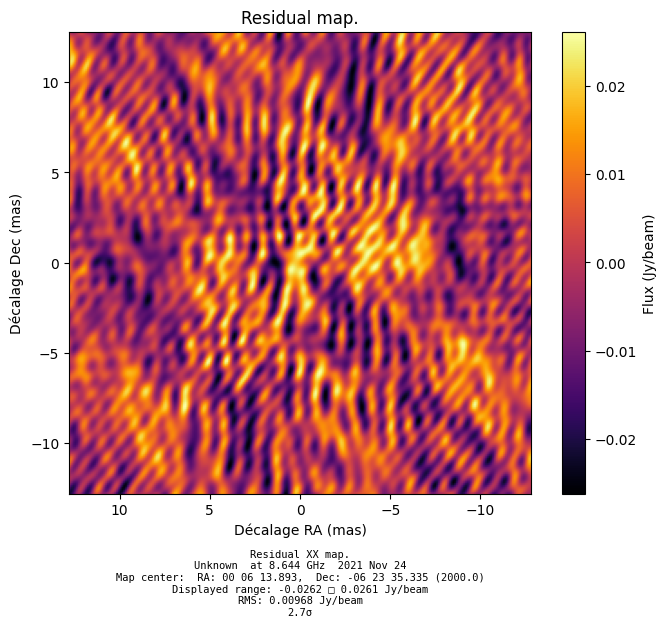

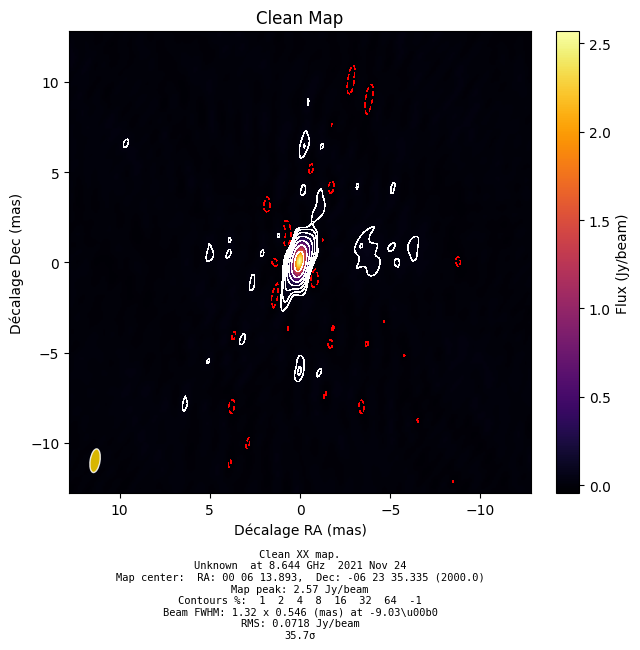

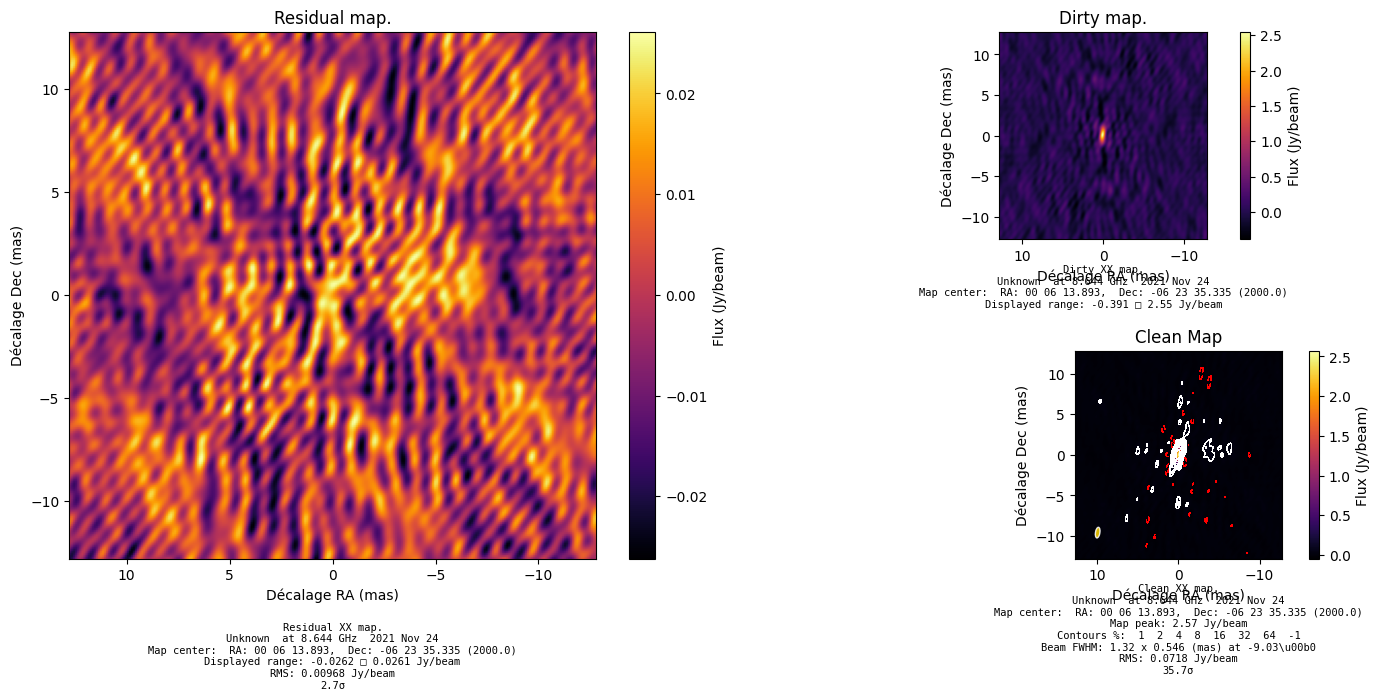

In [2]:
from difmap_wrapper import DifmapSession

with DifmapSession() as session:
    session.observe("tests/test_data/0003-066_X.SPLIT.1")
    session.obs.select(pol="RR")

    # ── Graphiques ──────────────────────────────────────────────
    session.vis.uvplot()
    session.vis.radplot()

    # ── Dirty map ───────────────────────────────────────────────
    dirty = session.imager.make_dirty_map(512, 0.1)
    session.vis.plot_image(dirty)

    # ── Residual + Clean ────────────────────────────────────────
    clean = session.imager.make_clean_map(512, 0.1, niter=500, gain=0.05, pol= "RR")
    residual = session.imager.get_residual_package(0.1)

    session.vis.plot_image(residual)   # carte résiduelle
    session.vis.plot_image(clean)      # carte propre : contours + faisceau + modèle

    # ── "All Maps" panel ─────────────────────────────────────────
    # à faire manuellement pour l'instant :
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(14, 7))
    gs = gridspec.GridSpec(2, 2, figure=fig)
    ax_res   = fig.add_subplot(gs[:, 0])   # résiduel grand à gauche
    ax_dirty = fig.add_subplot(gs[0, 1])   # dirty petit en haut à droite
    ax_clean = fig.add_subplot(gs[1, 1])   # clean petit en bas à droite

    session.vis.plot_image(residual, ax=ax_res,   show=False)
    session.vis.plot_image(dirty,    ax=ax_dirty,  show=False)
    session.vis.plot_image(clean,    ax=ax_clean,  show=False)
    plt.tight_layout()
    plt.show()


# ## 1. Chargement des données UV

In [3]:
# Création de la session Difmap (singleton)
session = DifmapSession()
session.observe(DATA_PATH)
selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)

print(f" Source      : {session.obs.source:<22}")
print(f" Polarisation: {selected_pol:<22}")
print(f" IFs         : {format_if_range(REQUESTED_IFS):<22}")


 Source      : 0003-066              Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1

 Polarisation: RR                    
 IFs         : tous                  
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2 

# ## 2. Inspection des visibilités

In [4]:
data = session.obs.get_data()

print(f"Visibilités chargées : {len(data['u']):,}")
print(f"IFs présents         : {unique_ifs(data)}")
print(f"Amplitude moyenne    : {data['amp'].mean():.4f} Jy")
print(f"Amplitude max        : {data['amp'].max():.4f} Jy")

Visibilités chargées : 13,072
IFs présents         : [1, 2, 3, 4]
Amplitude moyenne    : 2.8165 Jy
Amplitude max        : 4.3546 Jy


# ## 3. Couverture UV

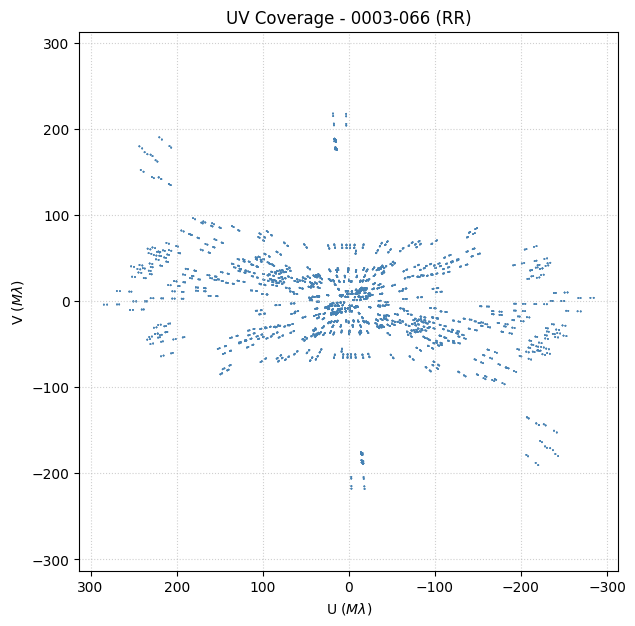

In [5]:
session.vis.uvplot(
    figsize=(7, 7),
    color="steelblue",
    s=1.5,
    alpha=0.35,
    title=f"UV Coverage - {session.obs.source} ({selected_pol})"
)
plt.show()

# ## 4. Radial Plot (Amplitude vs baseline)

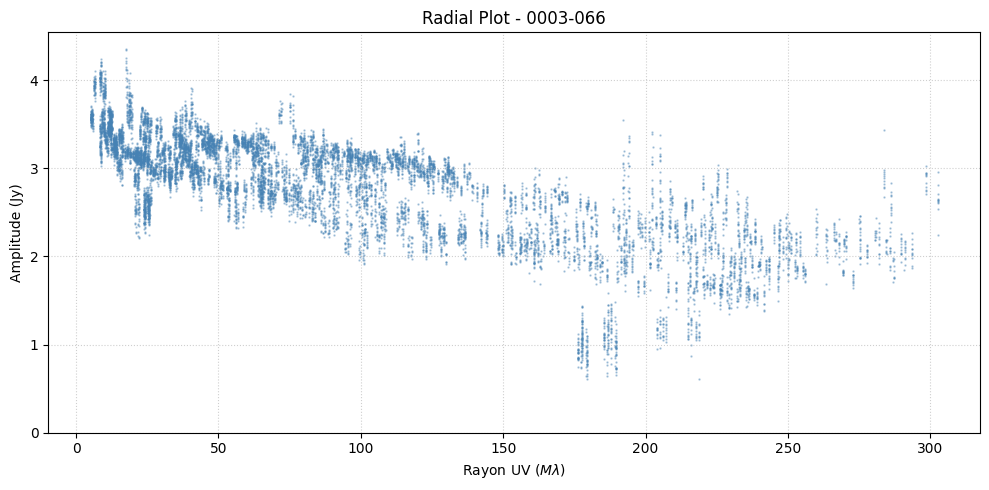

In [6]:
u, v = data['u'], data['v']
amp = data['amp']
uv_r = np.sqrt(u**2 + v**2) / 1e6  # Mλ

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(uv_r, amp, s=0.5, color='steelblue', alpha=0.4)
ax.set_xlabel(r"Rayon UV ($M\lambda$)")
ax.set_ylabel("Amplitude (Jy)")
ax.set_ylim(bottom=0)
ax.set_title(f"Radial Plot - {session.obs.source}")
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ## 5. Dirty Map (sans déconvolution)

Grille: 512×512 pixels, 0.1 mas/pixel
Beam: BMAJ=0.000 mas, BMIN=0.000 mas, BPA=0.0°
RMS: 121.197 mJy/beam
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


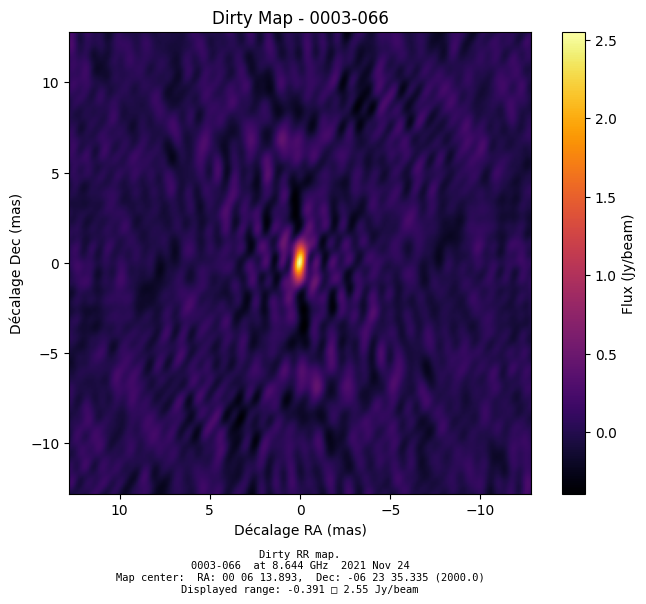

In [7]:
# Définition de la grille d'imagerie
session.imager.mapsize(MAP_SIZE, CELL_SIZE_MAS)
print(f"Grille: {MAP_SIZE}×{MAP_SIZE} pixels, {CELL_SIZE_MAS} mas/pixel")

# Calcul de la Dirty Map (FFT inverse)
session.imager.invert()
print_beam_info(session)

dirty_pkg = session.imager.get_map_package(CELL_SIZE_MAS)  # sauvegarde pour comparaison

session.vis.mapplot(
    title=f"Dirty Map - {session.obs.source}",
    cmap="inferno",
)
plt.show()

## 6. Premier CLEAN (sans fenêtre CLEAN)

=== PREMIER CLEAN — sans fenêtre ===
  niter  = 100  
  gain   = 0.05
  cutoff = 0.0 Jy/beam
Component: 050  -  total flux cleaned = 2.40333 Jy
Component: 100  -  total flux cleaned = 2.90978 Jy
Total flux subtracted in 100 components = 2.90978 Jy
Clean residual min=-0.076804 max=0.131075 Jy/beam
Clean residual mean=0.000772 rms=0.017787 Jy/beam
Clean map  min=-0.06816  max=2.5629 Jy/beam
Beam: BMAJ=1.323 mas, BMIN=0.546 mas, BPA=-9.0°
RMS: 73.114 mJy/beam


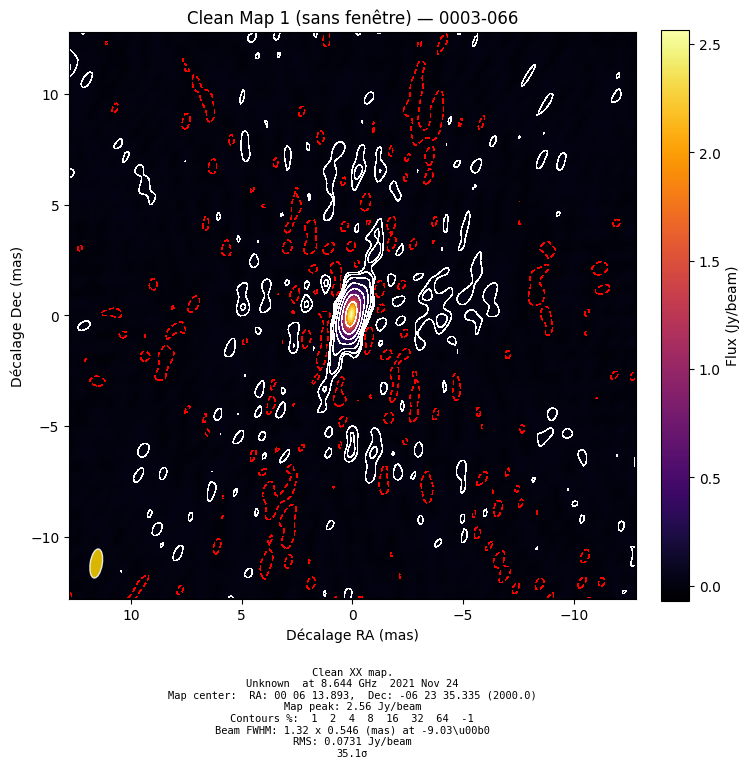

In [8]:
session.imager.clrmod()

print("=== PREMIER CLEAN — sans fenêtre ===")
print(f"  niter  = {CLEAN_NITER}  {'(arrêt au 1er négatif)' if CLEAN_NITER < 0 else ''}")
print(f"  gain   = {CLEAN_GAIN}")
print(f"  cutoff = {CLEAN_CUTOFF} Jy/beam")

session.imager.clean(niter=CLEAN_NITER, gain=CLEAN_GAIN, cutoff=CLEAN_CUTOFF)
session.imager.restore()

clean1_pkg   = session.imager.get_map_package(CELL_SIZE_MAS)
residual1_pkg = session.imager.get_residual_package(CELL_SIZE_MAS)
print_beam_info(session)

session.vis.plot_clean_map(
    clean1_pkg,
    title=f"Clean Map 1 (sans fenêtre) — {session.obs.source}",
    cmap="inferno",
    scale="linear",
    contour_mode="pct",
)
plt.show()

## 7. peakwin — Fenêtre automatique sur le résiduel

In [9]:
# peakwin fait trois choses en une seule commande :
#   1. Envoie les composantes CLEAN dans le modèle UV (established model)
#   2. Ré-inverse → la carte courante devient le résiduel vrai
#   3. Ajoute une fenêtre CLEAN autour du pic du résiduel
session.imager.peakwin()
print("✓ peakwin(): fenêtre créée autour du pic résiduel")

windows = session.imager._get_clean_windows()
print(f"Fenêtres actives ({len(windows)}):")
for i, (xa, xb, ya, yb) in enumerate(windows, 1):
    print(f"  {i}. X=[{xa:.1f}, {xb:.1f}] Y=[{ya:.1f}, {yb:.1f}] mas")

✓ peakwin(): fenêtre créée autour du pic résiduelAdded new window around map position (0, 0).

Fenêtres actives (1):
  1. X=[-0.3, 0.3] Y=[-0.7, 0.7] mas


## 8. Deuxième CLEAN (avec fenêtre peakwin)

In [1]:
print("=== DEUXIÈME CLEAN — avec fenêtre peakwin ===")
print(f"  niter  = {CLEAN_NITER}  {'(arrêt au 1er négatif)' if CLEAN_NITER < 0 else ''}")
print(f"  gain   = {CLEAN_GAIN}")
print(f"  cutoff = {CLEAN_CUTOFF} Jy/beam")

session.imager.clean(niter=CLEAN_NITER, gain=CLEAN_GAIN, cutoff=CLEAN_CUTOFF)
session.imager.restore()

clean2_pkg = session.imager.get_map_package(CELL_SIZE_MAS)

peak = session.imager.peak()
print(f"\nRésiduel post-CLEAN 2:")
print(f"  Pic résiduel : {peak['flux']:.4f} Jy/beam")

session.vis.plot_clean_map(
    clean2_pkg,
    title=f"Clean Map 2 (avec peakwin) — {session.obs.source}",
    cmap="inferno",
    scale="linear",
    contour_mode="pct",
)
plt.show()

=== DEUXIÈME CLEAN — avec fenêtre peakwin ===


NameError: name 'CLEAN_NITER' is not defined

## 9. Composantes du modèle CLEAN (delta components)

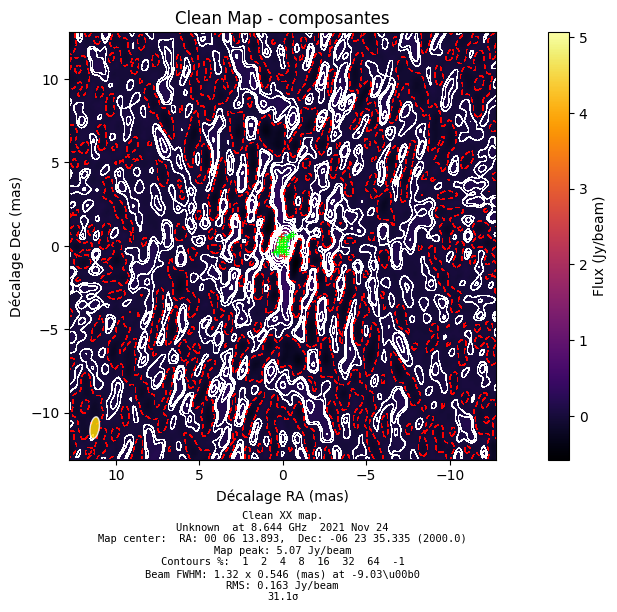

In [11]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

session.vis.plot_clean_map(
    clean2_pkg,
    ax=ax,
    title="Clean Map - composantes",
    cmap="inferno",
    scale="linear",
    contour_mode="pct",
    show_model=True,
    show=False,
)

plt.show()

## 10. Residual Map (post-2ème CLEAN)

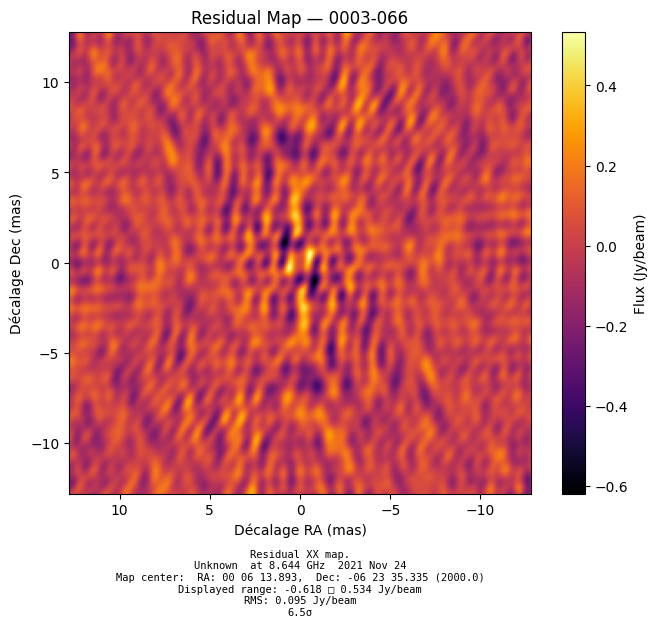

Résidu peak : 618.311 mJy/beam
Résidu RMS  : 94.985 mJy/beam
Résidu SNR  : 6.5


In [12]:
residual_pkg = session.imager.get_residual_package(CELL_SIZE_MAS)

session.vis.plot_image(
    residual_pkg,
    title=f"Residual Map — {session.obs.source}",
    figsize=(8, 6),
)
plt.show()

data_res = residual_pkg['data']
rms_res  = residual_pkg['info']['rms']
peak_res = float(np.nanmax(np.abs(data_res)))
print(f"Résidu peak : {peak_res * 1000:.3f} mJy/beam")
print(f"Résidu RMS  : {rms_res  * 1000:.3f} mJy/beam")
if rms_res > 0:
    print(f"Résidu SNR  : {peak_res / rms_res:.1f}")

## 11. Comparaison Résiduelle 1 vs Résiduelle 2

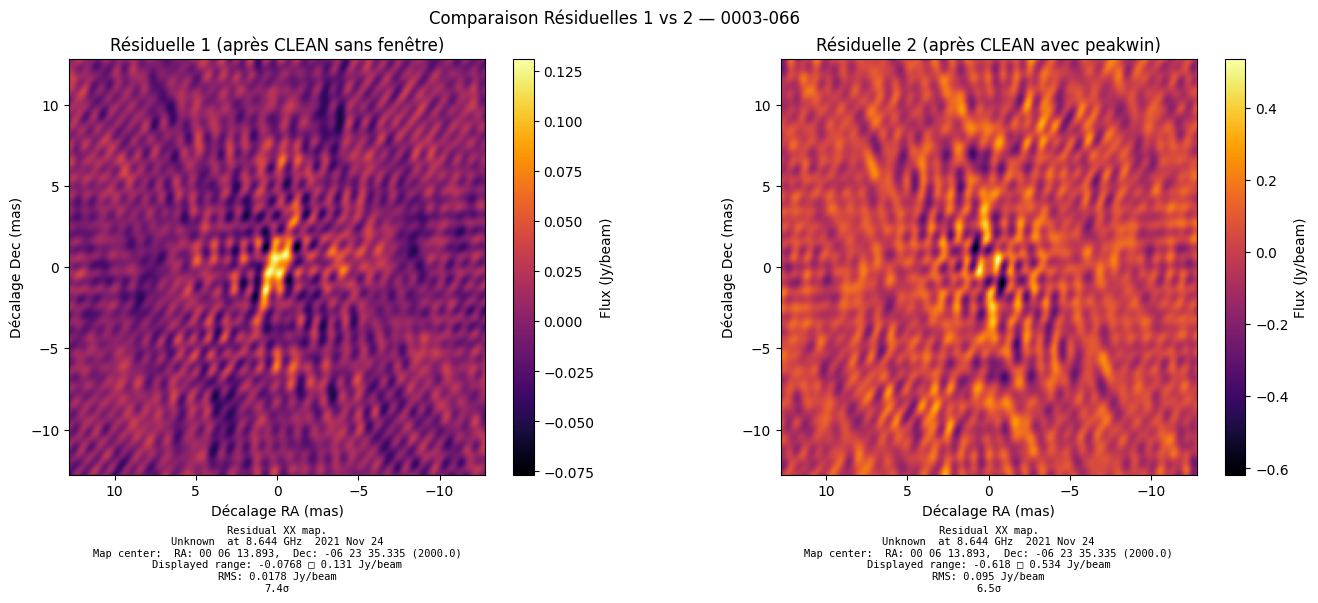

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

session.vis.plot_image(
    residual1_pkg,
    ax=axes[0],
    title="Résiduelle 1 (après CLEAN sans fenêtre)",
    cmap='inferno',
    show=False,
)
session.vis.plot_image(
    residual_pkg,
    ax=axes[1],
    title="Résiduelle 2 (après CLEAN avec peakwin)",
    cmap='inferno',
    show=False,
)
plt.suptitle(f"Comparaison Résiduelles 1 vs 2 — {session.obs.source}", fontsize=12)
plt.show()